## Experimenting with residence time in multiple boundary regions

In [2]:
import salishsea_tools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
from salishsea_tools import geo_tools

In [41]:
# Penn Cove 2 boundaries
outputf = '/ocean/ghoeven/MOAD/analysis-griffon/Ariane/PennCove_30d_2bound/new_compw_forward_01jan18/ariane_positions_quantitative.nc'
dataf = xr.open_dataset(outputf)

sections = pd.read_csv('/ocean/ghoeven/MOAD/ariane-2.3.0_03/PennCoveQNT_innerBound/sections.txt', sep=' ', names=list(range(24)))
sections = sections.apply(lambda row: row.dropna().values[:-1].astype(float), axis=1)
sections = pd.DataFrame(sections.tolist()).to_numpy()

sections

/tmp/ipykernel_1681663/2575716240.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dataf = xr.open_dataset(outputf)


array([[   1., -283., -283.,  211.,  217.,    1.,   40.],
       [   2.,  276.,  276.,  214.,  217.,    1.,   40.]])

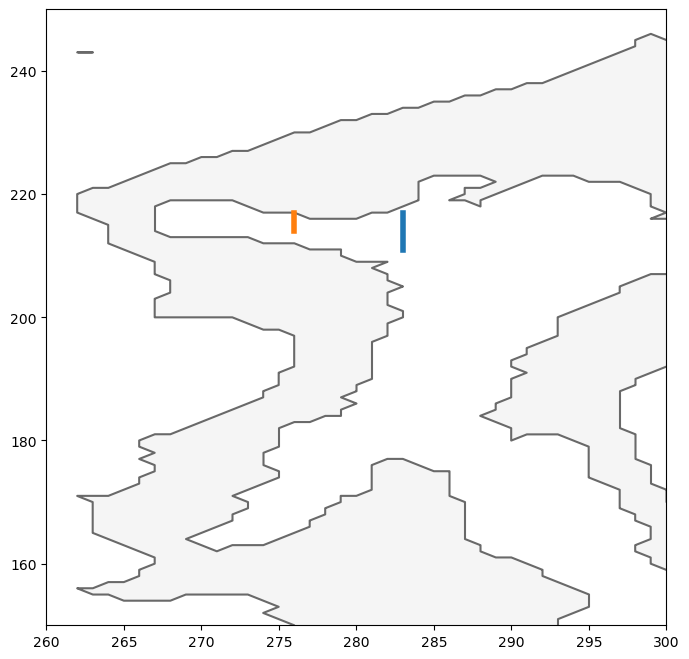

In [42]:
# Load grid and mask files
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask202108.nc')

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_ylim([150, 250])
ax.set_xlim([260, 300])
# Overlay domain landmask and coastline
ax.contourf(mesh.tmask[0, 0, ...], levels=[-0.01, 0.01], colors='whitesmoke')
ax.contour(mesh.tmask[0, 0, ...], levels=[-0.01, 0.01], colors='dimgray')

ax.plot(-sections[0, 1:3], sections[0,3:5], linewidth=4)
ax.plot(sections[1, 1:3], sections[1,3:5], linewidth=4)


Total mean time in (h) = 21.203257167229395
Total stdev of time in (h) = 28.72438317254292


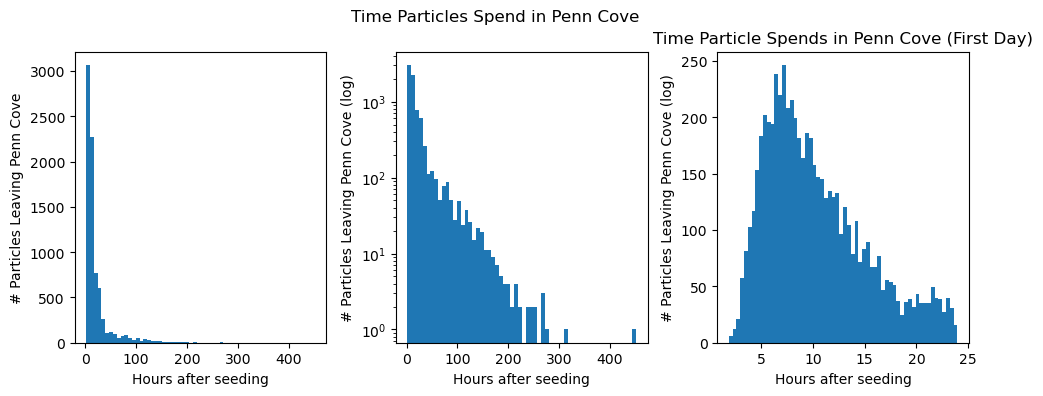

In [53]:
fs_mask = (dataf.final_section.values == 2)

dataf.final_age.values[fs_mask]

fage = dataf.final_age.values[fs_mask]
fage_days = fage / np.timedelta64(1, 'h')
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 4))
ax[0].hist(fage_days, bins=60, log=False, )
ax[0].set_xlabel('Hours after seeding')
ax[0].set_ylabel('# Particles Leaving Penn Cove')

ax[1].hist(fage_days, bins=60, log=True, )
ax[1].set_xlabel('Hours after seeding')
ax[1].set_ylabel('# Particles Leaving Penn Cove (log)')
fig.suptitle('Time Particles Spend in Penn Cove')
plt.tight_layout()

fage_day1 = fage_days[~(fage_days > 24)]
# fig, ax = plt.subplots(figsize=(4, 4))
ax[2].hist(fage_day1, bins=60, log=False, )
ax[2].set_title('Time Particle Spends in Penn Cove (First Day)')
ax[2].set_xlabel('Hours after seeding')
ax[2].set_ylabel('# Particles Leaving Penn Cove (log)')

print('Total mean time in (h) = ' + str(np.mean(fage_days)))
print('Total stdev of time in (h) = ' + str(np.std(fage_days)))

In [52]:
dataf

<xarray.Dataset> Size: 6MB
Dimensions:        (ntraj: 41933)
Dimensions without coordinates: ntraj
Data variables: (12/19)
    init_x         (ntraj) float64 335kB ...
    init_y         (ntraj) float64 335kB ...
    init_z         (ntraj) float64 335kB ...
    init_t         (ntraj) float64 335kB ...
    init_age       (ntraj) timedelta64[ns] 335kB ...
    init_transp    (ntraj) float64 335kB ...
    ...             ...
    init_lon       (ntraj) float64 335kB ...
    init_lat       (ntraj) float64 335kB ...
    init_depth     (ntraj) float64 335kB ...
    final_lon      (ntraj) float64 335kB ...
    final_lat      (ntraj) float64 335kB ...
    final_depth    (ntraj) float64 335kB ...
Attributes: (12/92)
    key_roms:                  .FALSE.
    key_mars:                  .FALSE.
    key_symphonie:             .FALSE.
    key_B2C_grid:              .FALSE.
    key_sequential:            .TRUE.
    key_alltracers:            .FALSE.
    ...                        ...
    indn_ve:                   30
    maxsize_ve:                6
    c_suffix_ve:               _grid_W.nc
    nc_var_ve:                 vovecrtz
    nc_var_eivw:               NONE
    nc_att_mask_ve:            NONE